In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, EsmModel
import lightning as L
from torchmetrics.regression import PearsonCorrCoef, SpearmanCorrCoef
import scipy.stats
import sklearn.metrics as skmetrics
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

MODEL_CHECKPOINT = 'facebook/esm2_t6_8M_UR50D'
EMBED_DIM = 320  # hidden dim for t6_8M

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
esm_model = EsmModel.from_pretrained(MODEL_CHECKPOINT).to(device).eval()
print("ESM-2 (8M) loaded!")

Using device: cuda


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ESM-2 (8M) loaded!


In [3]:
@torch.no_grad()
def get_residue_embeddings(sequence: str) -> torch.Tensor:
    """Returns per-residue embeddings (L, EMBED_DIM) — no CLS/EOS tokens."""
    inputs = tokenizer(sequence, return_tensors="pt").to(device)
    out = esm_model(**inputs)
    # strip <cls> (pos 0) and <eos> (pos -1)
    return out.last_hidden_state[0, 1:-1, :].cpu()  # (L, 320)

def find_mutation_position(wt_seq: str, mut_seq: str) -> int:
    """Returns index of first differing amino acid, or -1 if identical."""
    for i, (wt_aa, mut_aa) in enumerate(zip(wt_seq, mut_seq)):
        if wt_aa != mut_aa:
            return i
    return -1

def build_input_vector(mut_seq: str, wt_seq: str) -> torch.Tensor:
    """
    Builds a (6 * EMBED_DIM,) vector:
        [mut_at_i | wt_at_i | diff_at_i | mut_mean | wt_mean | diff_mean]
    Falls back to mean-only if no mutation position found.
    """
    mut_hidden = get_residue_embeddings(mut_seq)  # (L, 320)
    wt_hidden  = get_residue_embeddings(wt_seq)   # (L, 320)

    # global mean
    mut_mean  = mut_hidden.mean(dim=0)            # (320,)
    wt_mean   = wt_hidden.mean(dim=0)             # (320,)
    diff_mean = mut_mean - wt_mean                # (320,)

    # local at mutation position
    i = find_mutation_position(wt_seq, mut_seq)
    if i == -1:
        # no mutation found — duplicate mean as fallback
        mut_at_i  = mut_mean
        wt_at_i   = wt_mean
        diff_at_i = diff_mean
    else:
        mut_at_i  = mut_hidden[i]                 # (320,)
        wt_at_i   = wt_hidden[i]                  # (320,)
        diff_at_i = mut_at_i - wt_at_i            # (320,)

    return torch.cat([mut_at_i, wt_at_i, diff_at_i,
                      mut_mean,  wt_mean,  diff_mean])  # (1920,)


In [4]:
class ProtSeqDataset(Dataset):
    """
    CSV must contain columns:
        mut_type  : 'wt' | anything else
        aa_seq    : mutant amino-acid sequence
        wt_seq    : wildtype amino-acid sequence
        ddG_ML    : label (only needed for non-wt rows)
    """
    def __init__(self, csv_file: str):
        df = pd.read_csv(csv_file)
        # keep only mutation rows
        df = df[df.mut_type != 'wt'].reset_index(drop=True)
        self.labels = torch.tensor(df['ddG_ML'].values, dtype=torch.float32)

        print(f"Computing embeddings for {len(df)} variants in {csv_file} ...")
        self.embeddings = []
        for idx, row in df.iterrows():
            vec = build_input_vector(row['aa_seq'], row['wt_seq'])
            self.embeddings.append(vec)
            if (idx + 1) % 100 == 0:
                print(f"  {idx + 1}/{len(df)} done")
        print("Done!")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

In [5]:
dataset_train = ProtSeqDataset('data/mega_train.csv')
dataset_val   = ProtSeqDataset('data/mega_val.csv')

loader_train = DataLoader(dataset_train, batch_size=256, shuffle=True,  num_workers=4)
loader_val   = DataLoader(dataset_val,   batch_size=256, shuffle=False, num_workers=4)
print(f"Train: {len(dataset_train)} | Val: {len(dataset_val)}")

Computing embeddings for 215731 variants in data/mega_train.csv ...
  100/215731 done
  200/215731 done
  300/215731 done
  400/215731 done
  500/215731 done
  600/215731 done
  700/215731 done
  800/215731 done
  900/215731 done
  1000/215731 done
  1100/215731 done
  1200/215731 done
  1300/215731 done
  1400/215731 done
  1500/215731 done
  1600/215731 done
  1700/215731 done
  1800/215731 done
  1900/215731 done
  2000/215731 done
  2100/215731 done
  2200/215731 done
  2300/215731 done
  2400/215731 done
  2500/215731 done
  2600/215731 done
  2700/215731 done
  2800/215731 done
  2900/215731 done
  3000/215731 done
  3100/215731 done
  3200/215731 done
  3300/215731 done
  3400/215731 done
  3500/215731 done
  3600/215731 done
  3700/215731 done
  3800/215731 done
  3900/215731 done
  4000/215731 done
  4100/215731 done
  4200/215731 done
  4300/215731 done
  4400/215731 done
  4500/215731 done
  4600/215731 done
  4700/215731 done
  4800/215731 done
  4900/215731 done
  5000/215

In [76]:
INPUT_DIM = 6 * EMBED_DIM  # 1920

class StabModel(L.LightningModule):
    def __init__(self, input_dim=INPUT_DIM, lr=1e-5, dropout_prob=0.2):
        super().__init__()
        self.save_hyperparameters()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(64, 1)
        )
        self.loss_fn      = nn.MSELoss()
        self.lr           = lr
        self.val_pearson  = PearsonCorrCoef()
        self.val_spearman = SpearmanCorrCoef()

    def forward(self, x):
        return self.model(x).squeeze(1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y  = batch
        preds = self(x)
        self.log("val_loss",  self.loss_fn(preds, y),      on_epoch=True, prog_bar=True)
        self.log("val_pear",  self.val_pearson(preds, y),  on_epoch=True, prog_bar=True)
        self.log("val_spear", self.val_spearman(preds, y), on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=3, factor=0.5
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {'scheduler': scheduler, 'monitor': 'val_loss'}
        }

In [77]:
model   = StabModel()
trainer = L.Trainer(
    devices=1,
    max_epochs=20,
    callbacks=[
        L.pytorch.callbacks.EarlyStopping(monitor='val_loss', patience=5)
    ]
)
trainer.fit(model, loader_train, loader_val)

/home/course/bc_NN/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type             | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | model        | Sequential       |

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/course/bc_NN/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

RMSE:       0.47912219166755676
Pearson r:  PearsonRResult(statistic=0.68029755, pvalue=0.0)
Spearman r: SignificanceResult(statistic=0.6509570090791502, pvalue=0.0)


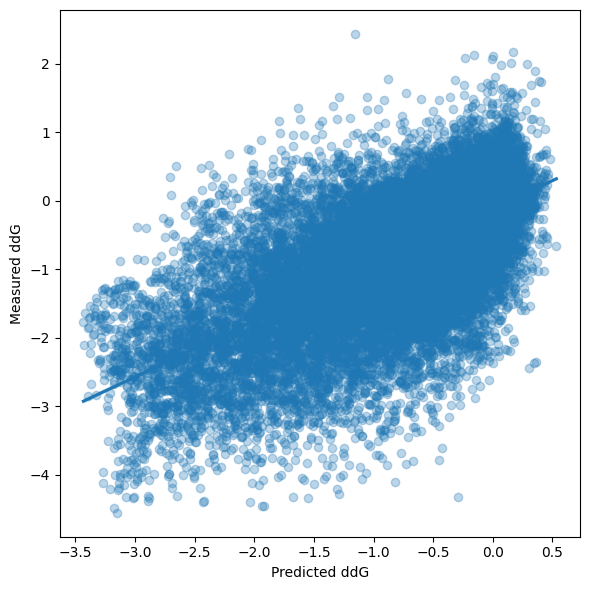

In [78]:
model.eval()
preds, all_y = [], []
with torch.no_grad():
    for x, y in loader_val:
        preds.append(model(x).squeeze().numpy())
        all_y.append(y.numpy())

preds = np.concatenate(preds)
all_y = np.concatenate(all_y)

print("RMSE:      ", skmetrics.mean_squared_error(all_y, preds))
print("Pearson r: ", scipy.stats.pearsonr(preds, all_y))
print("Spearman r:", scipy.stats.spearmanr(preds, all_y))

plt.figure(figsize=(6,6))
sns.regplot(x=preds, y=all_y, scatter_kws={'alpha':0.3})
plt.xlabel("Predicted ddG")
plt.ylabel("Measured ddG")
plt.tight_layout()
plt.show()

In [79]:
%reload_ext tensorboard
%tensorboard --logdir=lightning_logs


Reusing TensorBoard on port 6006 (pid 986870), started 18:25:40 ago. (Use '!kill 986870' to kill it.)

# Test set

In [82]:
import numpy as np
import scipy.stats
import sklearn.metrics as skmetrics

# ── Load & predict ────────────────────────────────────────────────────────────
dataset_test = ProtSeqDataset('data/mega_test.csv')
loader_test  = DataLoader(dataset_test, batch_size=256, shuffle=False, num_workers=4)


Computing embeddings for 28172 variants in data/mega_test.csv ...
  100/28172 done
  200/28172 done
  300/28172 done
  400/28172 done
  500/28172 done
  600/28172 done
  700/28172 done
  800/28172 done
  900/28172 done
  1000/28172 done
  1100/28172 done
  1200/28172 done
  1300/28172 done
  1400/28172 done
  1500/28172 done
  1600/28172 done
  1700/28172 done
  1800/28172 done
  1900/28172 done
  2000/28172 done
  2100/28172 done
  2200/28172 done
  2300/28172 done
  2400/28172 done
  2500/28172 done
  2600/28172 done
  2700/28172 done
  2800/28172 done
  2900/28172 done
  3000/28172 done
  3100/28172 done
  3200/28172 done
  3300/28172 done
  3400/28172 done
  3500/28172 done
  3600/28172 done
  3700/28172 done
  3800/28172 done
  3900/28172 done
  4000/28172 done
  4100/28172 done
  4200/28172 done
  4300/28172 done
  4400/28172 done
  4500/28172 done
  4600/28172 done
  4700/28172 done
  4800/28172 done
  4900/28172 done
  5000/28172 done
  5100/28172 done
  5200/28172 done
  5300/

Test set results (28172 samples)
Pearson  r:  0.615
Spearman ρ:  0.572
RMSE:        0.702


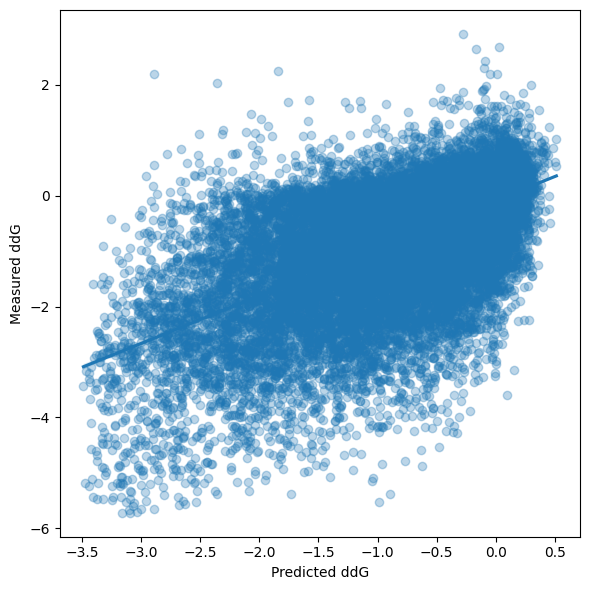

In [84]:
model.eval()
preds, all_y = [], []
with torch.no_grad():
    for x, y in loader_test:
        preds.append(model(x).squeeze().numpy())
        all_y.append(y.numpy())

preds = np.concatenate(preds)
all_y = np.concatenate(all_y)

# ── Metrics ───────────────────────────────────────────────────────────────────
print("=" * 45)
print(f"Test set results ({len(preds)} samples)")
print("=" * 45)
print(f"Pearson  r:  {scipy.stats.pearsonr(preds,  all_y).statistic:.3f}")
print(f"Spearman ρ:  {scipy.stats.spearmanr(preds, all_y).statistic:.3f}")
print(f"RMSE:        {skmetrics.mean_squared_error(all_y, preds):.3f}")
print("=" * 45)

plt.figure(figsize=(6,6))
sns.regplot(x=preds, y=all_y, scatter_kws={'alpha':0.3})
plt.xlabel("Predicted ddG")
plt.ylabel("Measured ddG")
plt.tight_layout()
plt.show()

Test set results (28172 samples)
Pearson  r:  0.615
Spearman ρ:  0.572
RMSE:        0.702


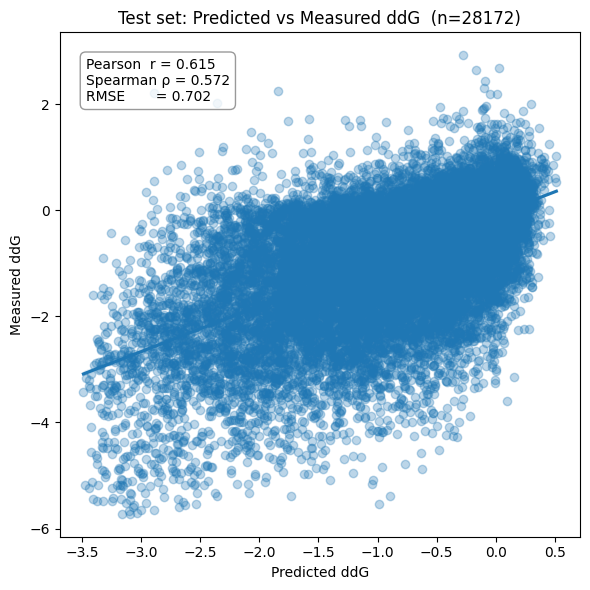

<Figure size 640x480 with 0 Axes>

In [171]:
model.eval()
preds, all_y = [], []
with torch.no_grad():
    for x, y in loader_test:
        preds.append(model(x).squeeze().numpy())
        all_y.append(y.numpy())
preds = np.concatenate(preds)
all_y = np.concatenate(all_y)

pearson  = scipy.stats.pearsonr(preds,  all_y)
spearman = scipy.stats.spearmanr(preds, all_y)
rmse     = skmetrics.mean_squared_error(all_y, preds)

print("=" * 45)
print(f"Test set results ({len(preds)} samples)")
print("=" * 45)
print(f"Pearson  r:  {pearson.statistic:.3f}")
print(f"Spearman ρ:  {spearman.statistic:.3f}")
print(f"RMSE:        {rmse:.3f}")
print("=" * 45)

fig, ax = plt.subplots(figsize=(6, 6))
sns.regplot(x=preds, y=all_y, scatter_kws={'alpha': 0.3}, ax=ax)
ax.text(0.05, 0.95,
        f"Pearson  r = {pearson.statistic:.3f}\n"
        f"Spearman ρ = {spearman.statistic:.3f}\n"
        f"RMSE       = {rmse:.3f}",
        transform=ax.transAxes,
        va='top', ha='left', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.8))
ax.set_xlabel("Predicted ddG")
ax.set_ylabel("Measured ddG")
ax.set_title(f"Test set: Predicted vs Measured ddG  (n={len(preds)})")
plt.tight_layout()
plt.show()
plt.savefig('outputs/test_final_model.png', dpi=300, bbox_inches='tight')

# Biological question:

In [85]:
def predict_ddG(mut_seq: str, wt_seq: str) -> float:
    """Predict ddG for any mutant/wildtype sequence pair."""
    model.eval()
    with torch.no_grad():
        x = build_input_vector(mut_seq, wt_seq).unsqueeze(0)  # (1, 1920)
        return model(x).item()

In [86]:
wt_sequence = str('MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRSSDFAKIINNTENLVRELLAVPDNYKVIFLQGGGCGQFSAVPLNLIGLKAGRCADYVVTGAWSAKAAEEAKKFGTINIVHPKLGSYTKIPDPSTWNLNPDASYVYYCANETVHGVEFDFIPDVKGAVLVCDMSSNFLSKPVDVSKFGVIFAGAQKNVGSAGVTVVIVRDDLLGFALRECPSVLEYKVQAGNSSLYNTPPCFSIYVMGLVLEWIKNNGGAAAMEKLSSIKSQTIYEIIDNSQGFYVCPVEPQNRSKMNIPFRIGNAKGDDALEKRFLDKALELNMLSLKGHRSVGGIRASLYNAVTIEDVQKLAAFMKKFLEMHQL')

df_predict = pd.read_csv('mutated_sequences_output.csv')
print(f"Loaded {len(df_predict)} mutations")
print(df_predict.head())


Loaded 199 mutations
      Mutation                                      Full_Sequence     score  \
0  p.Tyr249Cys  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.266467   
1  p.Glu366Asp  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.211577   
2  p.Lys311Asn  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.176802   
3  p.Ala359Thr  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.163540   
4  p.Ile351Val  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.159228   

         se  
0  0.030693  
1  0.033582  
2  0.035377  
3  0.034764  
4  0.029751  


In [87]:
model.eval()

predicted_ddG = []
for idx, row in df_predict.iterrows():
    mut_seq = row['Full_Sequence']
    ddg = predict_ddG(mut_seq, wt_sequence)
    predicted_ddG.append(ddg)
    if (idx + 1) % 10 == 0:
        print(f"  {idx + 1}/{len(df_predict)} done")

df_predict['ddG_predicted'] = predicted_ddG
print("Done!")
print(df_predict.head())

  10/199 done
  20/199 done
  30/199 done
  40/199 done
  50/199 done
  60/199 done
  70/199 done
  80/199 done
  90/199 done
  100/199 done
  110/199 done
  120/199 done
  130/199 done
  140/199 done
  150/199 done
  160/199 done
  170/199 done
  180/199 done
  190/199 done
Done!
      Mutation                                      Full_Sequence     score  \
0  p.Tyr249Cys  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.266467   
1  p.Glu366Asp  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.211577   
2  p.Lys311Asn  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.176802   
3  p.Ala359Thr  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.163540   
4  p.Ile351Val  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.159228   

         se  ddG_predicted  
0  0.030693      -1.448708  
1  0.033582       0.047238  
2  0.035377      -0.012198  
3  0.034764       0.085316  
4  0.029751      -0.070248  


In [88]:
output_path = 'mutated_sequences_with_ddG.csv'
df_predict.to_csv(output_path, index=False)
print(f"Saved to {output_path}")
print(df_predict[['Mutation', 'Full_Sequence', 'score', 'se', 'ddG_predicted']].head(10))

Saved to mutated_sequences_with_ddG.csv
      Mutation                                      Full_Sequence     score  \
0  p.Tyr249Cys  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.266467   
1  p.Glu366Asp  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.211577   
2  p.Lys311Asn  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.176802   
3  p.Ala359Thr  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.163540   
4  p.Ile351Val  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.159228   
5  p.Glu113Val  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.155395   
6  p.Glu223Ala  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.154499   
7  p.Asn309Ser  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.152909   
8   p.Ala95Glu  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.151507   
9   p.Cys80Tyr  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.145226   

         se  ddG_predicted  
0  0.030693      -1.448708  
1  0.033582       0.047238  
2  

Spearman ρ: 0.271  (p = 1.11e-04)
Kendall  τ: 0.187  (p = 8.81e-05)
Pearson  r: 0.276  (p = 7.74e-05)


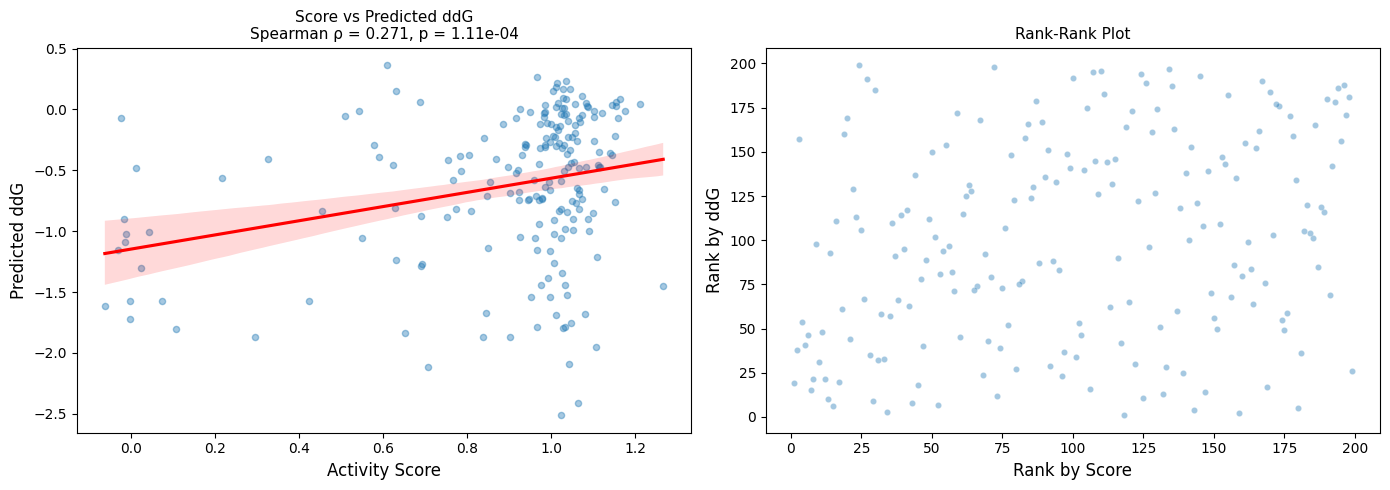

<Figure size 640x480 with 0 Axes>


Top 10 by Score vs their ddG rank:
   Mutation    score  ddG_predicted  rank_ddG
p.Tyr249Cys 1.266467      -1.448708      26.0
p.Glu366Asp 1.211577       0.047238     181.0
p.Lys311Asn 1.176802      -0.012198     171.0
p.Ala359Thr 1.163540       0.085316     188.0
p.Ile351Val 1.159228      -0.070248     156.0
p.Glu113Val 1.155395       0.064962     186.0
p.Glu223Ala 1.154499       0.031688     178.0
p.Asn309Ser 1.152909      -0.219771     142.0
 p.Ala95Glu 1.151507      -0.760911      69.0
 p.Cys80Tyr 1.145226       0.036439     180.0

Top 10 by ddG vs their score rank:
   Mutation  ddG_predicted    score  rank_score
 p.Pro87Leu       0.363074 0.608737        24.0
p.Asp167Asn       0.268595 0.965444        72.0
  p.Asp2Tyr       0.229733 1.035268       134.0
p.Ser189Cys       0.219023 1.014819       110.0
p.Glu114Ala       0.182928 1.011224       107.0
 p.Asn58Ser       0.167989 1.027464       124.0
  p.Asp2Asn       0.165230 1.045338       145.0
 p.Asn54Ile       0.152964 1.004221   

In [148]:
df = pd.read_csv('mutated_sequences_with_ddG.csv')

# NOTE: ddG here is defined as dG(wt) - dG(mt)
# positive ddG = mutant less stable than WT
# flip sign below if needed:
# df['ddG_predicted'] = -df['ddG_predicted']

spearman = scipy.stats.spearmanr(df['score'], df['ddG_predicted'])
kendall  = scipy.stats.kendalltau(df['score'], df['ddG_predicted'])
pearson  = scipy.stats.pearsonr(df['score'],  df['ddG_predicted'])

print("=" * 45)
print(f"Spearman ρ: {spearman.statistic:.3f}  (p = {spearman.pvalue:.2e})")
print(f"Kendall  τ: {kendall.statistic:.3f}  (p = {kendall.pvalue:.2e})")
print(f"Pearson  r: {pearson.statistic:.3f}  (p = {pearson.pvalue:.2e})")
print("=" * 45)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter with regression line
ax = axes[0]
sns.regplot(
    data=df, x='score', y='ddG_predicted', ax=ax,
    scatter_kws={'alpha': 0.4, 's': 20},
    line_kws={'color': 'red'}
)
ax.set_xlabel("Activity Score", fontsize=12)
ax.set_ylabel("Predicted ddG", fontsize=12)
ax.set_title(
    f"Score vs Predicted ddG\n"
    f"Spearman ρ = {spearman.statistic:.3f}, p = {spearman.pvalue:.2e}",
    fontsize=11
)

# Right: rank-rank scatter
ax2 = axes[1]
df['rank_score'] = df['score'].rank()
df['rank_ddG']   = df['ddG_predicted'].rank()
sns.scatterplot(
    data=df, x='rank_score', y='rank_ddG', ax=ax2,
    alpha=0.4, s=20
)
ax2.set_xlabel("Rank by Score", fontsize=12)
ax2.set_ylabel("Rank by ddG", fontsize=12)
ax2.set_title("Rank-Rank Plot", fontsize=11)

plt.tight_layout()
plt.savefig('data/score_vs_ddG_comparison.png', dpi=150)
plt.show()
plt.savefig('outputs/regression_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Top 10 comparisons
print("\nTop 10 by Score vs their ddG rank:")
top_score = df.nlargest(10, 'score')[['Mutation', 'score', 'ddG_predicted', 'rank_ddG']]
print(top_score.to_string(index=False))

print("\nTop 10 by ddG vs their score rank:")
top_ddg = df.nlargest(10, 'ddG_predicted')[['Mutation', 'ddG_predicted', 'score', 'rank_score']]
print(top_ddg.to_string(index=False))

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats
import re
import torch
import os

os.makedirs('outputs', exist_ok=True)

In [157]:
df = pd.read_csv('mutated_sequences_with_ddG.csv')

wt_sequence = str("MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRSSDFAKIINNTENLVRELLAVPDNYKVIFLQGGGCGQFSAVPLNLIGLKAGRCADYVVTGAWSAKAAEEAKKFGTINIVHPKLGSYTKIPDPSTWNLNPDASYVYYCANETVHGVEFDFIPDVKGAVLVCDMSSNFLSKPVDVSKFGVIFAGAQKNVGSAGVTVVIVRDDLLGFALRECPSVLEYKVQAGNSSLYNTPPCFSIYVMGLVLEWIKNNGGAAAMEKLSSIKSQTIYEIIDNSQGFYVCPVEPQNRSKMNIPFRIGNAKGDDALEKRFLDKALELNMLSLKGHRSVGGIRASLYNAVTIEDVQKLAAFMKKFLEMHQL")  # your full WT

DDG_THRESH   = 0.0
SCORE_THRESH = 1.0

# Clip scores at 0
df['score'] = df['score'].clip(lower=0.0)

# Score confidence using se
df['gt_positive'] = (df['score'] - 2 * df['se'].abs()) > SCORE_THRESH
df['gt_negative']  = (df['score'] + 2 * df['se'].abs()) < SCORE_THRESH
df['gt_uncertain'] = ~df['gt_positive'] & ~df['gt_negative']

print(f"Loaded {len(df)} mutations")
print(f"gt_positive: {df['gt_positive'].sum()}")
print(f"gt_negative: {df['gt_negative'].sum()}")
print(f"gt_uncertain: {df['gt_uncertain'].sum()}")

Loaded 199 mutations
gt_positive: 43
gt_negative: 64
gt_uncertain: 92


In [158]:
def parse_position(mut_str):
    match = re.search(r'(\d+)', str(mut_str))
    return int(match.group(1)) if match else None

df['position'] = df['Mutation'].apply(parse_position)
print(f"Positions range: {df['position'].min()} – {df['position'].max()}")

Positions range: 2 – 369


In [159]:
# Need ESM2 + model in memory from training notebook
# If reloading:
# model = StabModel.load_from_checkpoint('path/to/checkpoint.ckpt')
# model.eval()

AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")

records = []
for pos in range(len(wt_sequence)):
    wt_aa = wt_sequence[pos]
    for mut_aa in AA_LIST:
        mut_seq = wt_sequence[:pos] + mut_aa + wt_sequence[pos+1:]
        records.append({
            'position': pos + 1,    # 1-indexed to match mutation strings
            'wt_aa':    wt_aa,
            'mut_aa':   mut_aa,
            'is_wt':    mut_aa == wt_aa,
            'mut_seq':  mut_seq
        })

df_scan = pd.DataFrame(records)
print(f"Generated {len(df_scan)} variants "
      f"({len(wt_sequence)} positions × 20 AA)")

Generated 7400 variants (370 positions × 20 AA)


In [160]:
model.eval()
ddg_values = []
total = len(df_scan)

for idx, row in df_scan.iterrows():
    if row['is_wt']:
        ddg_values.append(0.0)
    else:
        ddg_values.append(predict_ddG(row['mut_seq'], wt_sequence))
    if (idx + 1) % 500 == 0:
        print(f"  {idx + 1}/{total} done")

df_scan['ddG_predicted'] = ddg_values
df_scan.to_csv('data/full_scan.csv', index=False)
print("Saved to data/full_scan.csv")

  500/7400 done
  1000/7400 done
  1500/7400 done
  2000/7400 done
  2500/7400 done
  3000/7400 done
  3500/7400 done
  4000/7400 done
  4500/7400 done
  5000/7400 done
  5500/7400 done
  6000/7400 done
  6500/7400 done
  7000/7400 done
Saved to data/full_scan.csv


In [161]:
# For each position, compute mean and std across all 20 AA substitutions
# excluding the WT itself (is_wt == False)
pos_stats = (
    df_scan[~df_scan['is_wt']]
    .groupby('position')['ddG_predicted']
    .agg(
        ddG_pos_mean = 'mean',
        ddG_pos_std  = 'std',
        ddG_pos_min  = 'min',
        ddG_pos_max  = 'max'
    )
    .reset_index()
)

# SE = std / sqrt(19)  (19 possible substitutions per position)
pos_stats['ddG_pos_se'] = pos_stats['ddG_pos_std'] / np.sqrt(19)

print(pos_stats.head(10))
print(f"\nMean positional SE: {pos_stats['ddG_pos_se'].mean():.4f}")

   position  ddG_pos_mean  ddG_pos_std  ddG_pos_min  ddG_pos_max  ddG_pos_se
0         1     -0.029267     0.130833    -0.266358     0.142951    0.030015
1         2      0.212999     0.065203     0.063004     0.298996    0.014959
2         3     -0.055059     0.182297    -0.662049     0.150038    0.041822
3         4     -0.184948     0.108323    -0.468549    -0.021263    0.024851
4         5     -0.043626     0.260541    -0.647982     0.299680    0.059772
5         6     -0.236583     0.301568    -0.987019     0.168932    0.069184
6         7     -0.851684     0.470631    -1.721099    -0.051661    0.107970
7         8     -1.031877     0.554928    -1.923069    -0.188218    0.127309
8         9     -1.001091     0.506163    -2.180002    -0.193805    0.116122
9        10     -2.061077     0.406756    -2.512178    -1.206916    0.093316

Mean positional SE: 0.0852


In [162]:
df = df.merge(pos_stats, on='position', how='left')

# For each mutation in df, also get its individual ddG from the scan
# (more precise than the one already in df since scan is systematic)
scan_lookup = df_scan.set_index(['position', 'mut_aa'])['ddG_predicted'].to_dict()

def get_scan_ddg(row):
    import re
    # parse mut_aa from mutation string e.g. "p.Ala23Gly" → mut_aa = 'G'
    aa3to1 = {'Ala':'A','Arg':'R','Asn':'N','Asp':'D','Cys':'C',
               'Gln':'Q','Glu':'E','Gly':'G','His':'H','Ile':'I',
               'Leu':'L','Lys':'K','Met':'M','Phe':'F','Pro':'P',
               'Ser':'S','Thr':'T','Trp':'W','Tyr':'Y','Val':'V'}
    match = re.match(r'p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})', str(row['Mutation']))
    if match:
        mut_aa = aa3to1.get(match.group(3), None)
        pos    = int(match.group(2))
        return scan_lookup.get((pos, mut_aa), row['ddG_predicted'])
    return row['ddG_predicted']

df['ddG_scan'] = df.apply(get_scan_ddg, axis=1)
print("Merged positional stats into main dataframe")

Merged positional stats into main dataframe


In [163]:
COLOR_MAP = {
    'Hyperactive + stabilizing':   '#2ecc71',  # green
    'Hyperactive + destabilizing': '#3498db',  # blue
    'Damaging + stabilizing':      '#e67e22',  # orange
    'Damaging + destabilizing':    '#e74c3c',  # red
    'Uncertain':                   '#95a5a6',  # grey
}


LABELS = COLOR_MAP.keys()

# ddG confidence using positional SE from scan
df['ddg_confident_pos'] = (df['ddG_scan'] - 2 * df['ddG_pos_se']) > DDG_THRESH
df['ddg_confident_neg'] = (df['ddG_scan'] + 2 * df['ddG_pos_se']) < DDG_THRESH
df['ddg_uncertain']     = ~df['ddg_confident_pos'] & ~df['ddg_confident_neg']

def assign_category(row):
    pred_stabilizing = row['ddG_scan'] > DDG_THRESH

    # Uncertain if either axis confidence interval crosses its threshold
    if row['gt_uncertain'] or row['ddg_uncertain']:
        return 'Uncertain'
    elif row['gt_positive']:
        return 'Hyperactive + stabilizing'   if pred_stabilizing \
               else 'Hyperactive + destabilizing'
    else:
        return 'Damaging + stabilizing'      if pred_stabilizing \
               else 'Damaging + destabilizing'

df['category'] = df.apply(assign_category, axis=1)

print("Category counts:")
print(df['category'].value_counts().to_string())

Category counts:
category
Uncertain                      118
Damaging + destabilizing        54
Hyperactive + destabilizing     26
Damaging + stabilizing           1


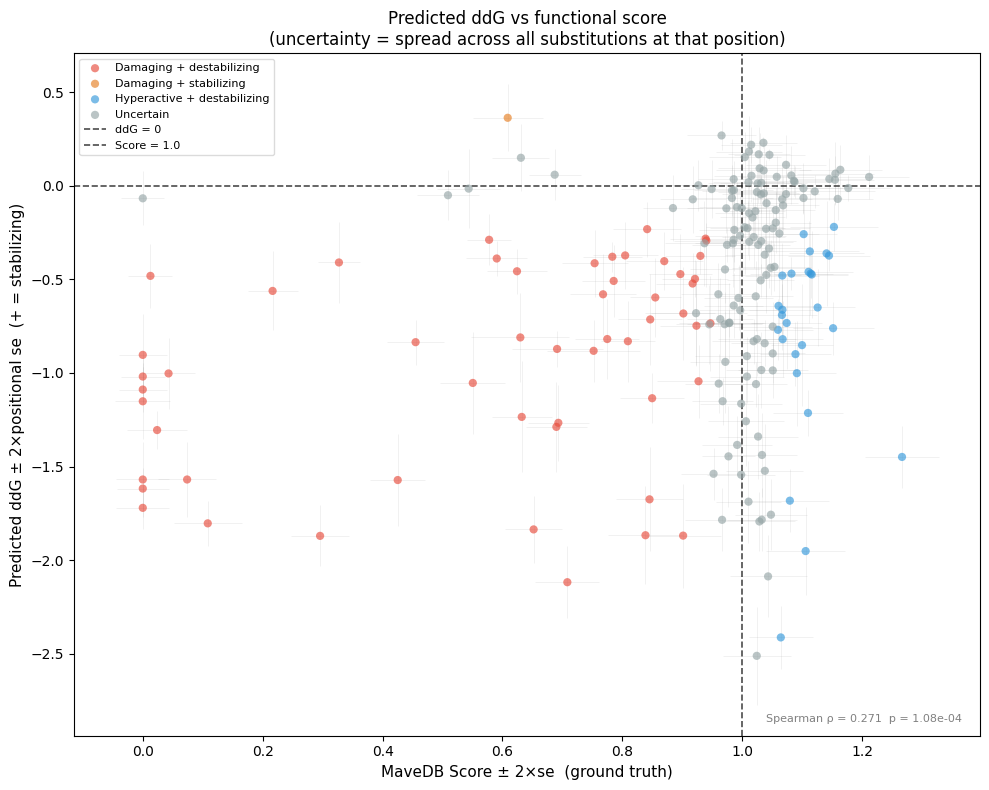

In [164]:
fig, ax = plt.subplots(figsize=(10, 8))

for cat, group in df.groupby('category'):
    ax.scatter(
        group['score'],
        group['ddG_scan'],
        c=COLOR_MAP[cat],
        label=cat,
        alpha=0.65, s=35, edgecolors='none', zorder=3
    )

# Error bars
# x: score SE from MaveDB
# y: positional SE from full scan (spread across all 19 mutations at that position)
ax.errorbar(
    df['score'], df['ddG_scan'],
    xerr=2 * df['se'].abs(),
    yerr=2 * df['ddG_pos_se'],
    fmt='none', alpha=0.15, color='gray', linewidth=0.5, zorder=2
)

# Threshold lines
ax.axhline(DDG_THRESH,   color='black', linestyle='--',
           linewidth=1.2, alpha=0.7, label='ddG = 0')
ax.axvline(SCORE_THRESH, color='black', linestyle='--',
           linewidth=1.2, alpha=0.7, label='Score = 1.0')

spearman = scipy.stats.spearmanr(df['score'], df['ddG_scan'])
ax.text(0.98, 0.02,
        f"Spearman ρ = {spearman.statistic:.3f}  p = {spearman.pvalue:.2e}",
        transform=ax.transAxes, ha='right', fontsize=8, color='gray')

ax.set_xlabel("MaveDB Score ± 2×se  (ground truth)", fontsize=11)
ax.set_ylabel("Predicted ddG ± 2×positional se  (+ = stabilizing)", fontsize=11)
ax.set_title("Predicted ddG vs functional score\n"
             "(uncertainty = spread across all substitutions at that position)",
             fontsize=12)
ax.legend(fontsize=8, loc='upper left', framealpha=0.7)

plt.tight_layout()
plt.savefig('outputs/quadrant_scatter_final.png', dpi=300, bbox_inches='tight')
plt.show()

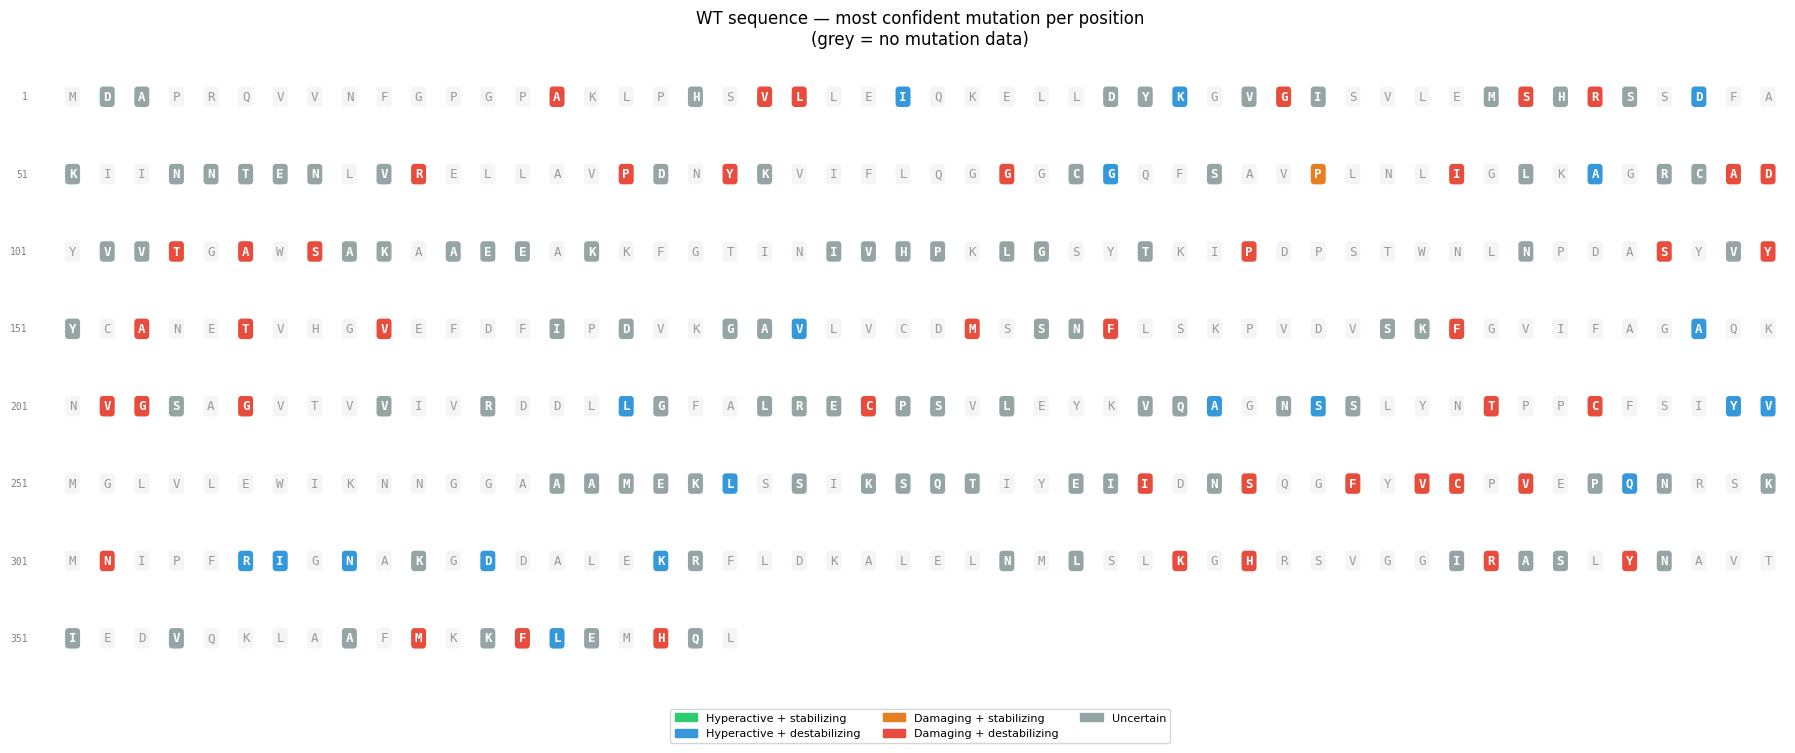

Saved to outputs/colourindex_final.png


In [165]:
CHARS_PER_ROW = 50

df['dist_score'] = (df['score'] - SCORE_THRESH).abs()
df['dist_ddg']   = (df['ddG_scan'] - DDG_THRESH).abs()
df['dist_total'] = df['dist_score'] + df['dist_ddg']

pos_most_confident = (
    df.loc[df.groupby('position')['dist_total'].idxmax()]
    [['position', 'category', 'dist_total', 'score', 'ddG_scan', 'ddG_pos_se']]
    .reset_index(drop=True)
)
pos_to_cat = dict(zip(pos_most_confident['position'],
                      pos_most_confident['category']))

rows   = [wt_sequence[i:i+CHARS_PER_ROW]
          for i in range(0, len(wt_sequence), CHARS_PER_ROW)]
n_rows = len(rows)

fig, ax = plt.subplots(figsize=(18, n_rows * 0.7 + 2))
ax.set_xlim(0, CHARS_PER_ROW)
ax.set_ylim(-0.5, n_rows)
ax.axis('off')

for row_idx, row_seq in enumerate(rows):
    y = n_rows - row_idx - 1
    for col_idx, aa in enumerate(row_seq):
        pos = row_idx * CHARS_PER_ROW + col_idx + 1
        cat = pos_to_cat.get(pos, None)

        facecolor  = COLOR_MAP[cat] if cat else '#f5f5f5'
        textcolor  = 'white'        if cat else '#999999'
        fontweight = 'bold'         if cat else 'normal'

        ax.text(
            col_idx + 0.5, y + 0.5, aa,
            ha='center', va='center',
            fontsize=9, fontweight=fontweight, color=textcolor,
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor=facecolor, edgecolor='none')
        )

    ax.text(-0.8, y + 0.5, str(row_idx * CHARS_PER_ROW + 1),
            ha='right', va='center', fontsize=7,
            color='gray', fontfamily='monospace')

legend_handles = [
    mpatches.Patch(color=COLOR_MAP[cat], label=cat)
    for cat in COLOR_MAP
]
ax.legend(handles=legend_handles, loc='lower center',
          bbox_to_anchor=(0.5, -0.05),
          ncol=3, fontsize=8, framealpha=0.8)
ax.set_title(
    "WT sequence — most confident mutation per position\n"
    "(grey = no mutation data)",
    fontsize=12, pad=10
)

plt.tight_layout()
plt.savefig('outputs/colourindex_final.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to outputs/colourindex_final.png")

Score std: 0.096  → band: [0.904, 1.096]
ddG std:   0.203  → band: [-0.203, 0.203]

Category counts:
category
Uncertain                      138
Damaging + destabilizing        46
Hyperactive + destabilizing     14
Damaging + stabilizing           1


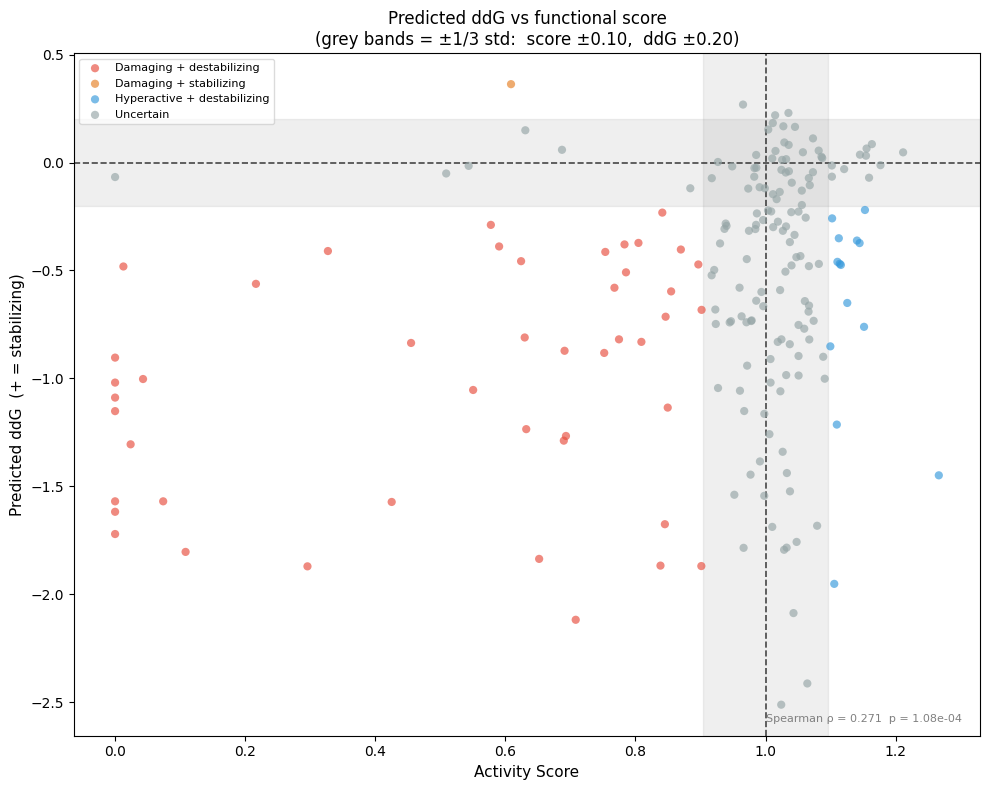

Saved to outputs/quadrant_scatter_stdbands.png


In [166]:
fig, ax = plt.subplots(figsize=(10, 8))

# ── Margins from std of all points on each axis ───────────────────────────────
x_margin = (df['score'].std())/3
y_margin = (df['ddG_scan'].std())/3

print(f"Score std: {x_margin:.3f}  → band: [{SCORE_THRESH-x_margin:.3f}, {SCORE_THRESH+x_margin:.3f}]")
print(f"ddG std:   {y_margin:.3f}  → band: [{DDG_THRESH-y_margin:.3f}, {DDG_THRESH+y_margin:.3f}]")

# ── Recompute categories using std-based margins ──────────────────────────────
df['gt_positive']  = df['score']    > SCORE_THRESH + x_margin
df['gt_negative']  = df['score']    < SCORE_THRESH - x_margin
df['gt_uncertain'] = ~df['gt_positive'] & ~df['gt_negative']

df['ddg_confident_pos'] = df['ddG_scan'] > DDG_THRESH + y_margin
df['ddg_confident_neg'] = df['ddG_scan'] < DDG_THRESH - y_margin
df['ddg_uncertain']     = ~df['ddg_confident_pos'] & ~df['ddg_confident_neg']

df['category'] = df.apply(assign_category, axis=1)

print("\nCategory counts:")
print(df['category'].value_counts().to_string())

# ── Grey bands ────────────────────────────────────────────────────────────────
ax.axvspan(
    SCORE_THRESH - x_margin, SCORE_THRESH + x_margin,
    color='gray', alpha=0.12, zorder=1
)
ax.axhspan(
    DDG_THRESH - y_margin, DDG_THRESH + y_margin,
    color='gray', alpha=0.12, zorder=1
)

# ── Scatter ───────────────────────────────────────────────────────────────────
for cat, group in df.groupby('category'):
    ax.scatter(
        group['score'],
        group['ddG_scan'],
        c=COLOR_MAP[cat],
        label=cat,
        alpha=0.65, s=35, edgecolors='none', zorder=3
    )

# Threshold lines
ax.axhline(DDG_THRESH,   color='black', linestyle='--', linewidth=1.2, alpha=0.7)
ax.axvline(SCORE_THRESH, color='black', linestyle='--', linewidth=1.2, alpha=0.7)

spearman = scipy.stats.spearmanr(df['score'], df['ddG_scan'])
ax.text(0.98, 0.02,
        f"Spearman ρ = {spearman.statistic:.3f}  p = {spearman.pvalue:.2e}",
        transform=ax.transAxes, ha='right', fontsize=8, color='gray')

ax.set_xlabel("Activity Score", fontsize=11)
ax.set_ylabel("Predicted ddG  (+ = stabilizing)", fontsize=11)
ax.set_title(
    f"Predicted ddG vs functional score\n"
    f"(grey bands = ±1/3 std:  score ±{x_margin:.2f},  ddG ±{y_margin:.2f})",
    fontsize=12
)
ax.legend(fontsize=8, loc='upper left', framealpha=0.7)

plt.tight_layout()
plt.savefig('outputs/quadrant_scatter_stdbands.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to outputs/quadrant_scatter_stdbands.png")

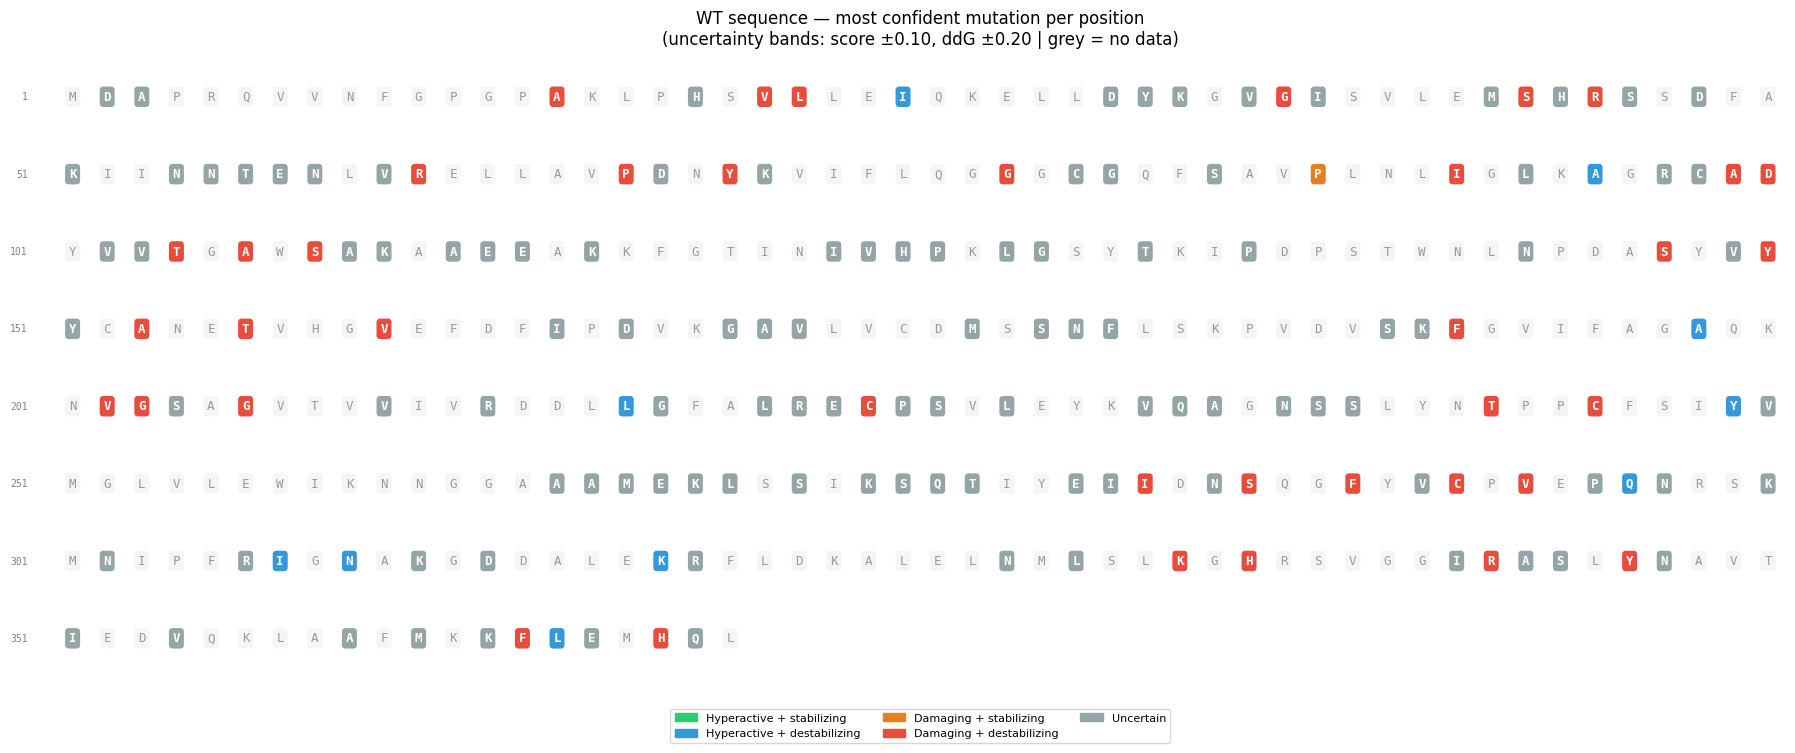

Saved to outputs/colourindex_stdbands.png


In [167]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('outputs', exist_ok=True)

CHARS_PER_ROW = 50

# ── Most confident mutation per position ──────────────────────────────────────
df['dist_score'] = (df['score']    - SCORE_THRESH).abs()
df['dist_ddg']   = (df['ddG_scan'] - DDG_THRESH).abs()
df['dist_total'] = df['dist_score'] + df['dist_ddg']

pos_most_confident = (
    df.loc[df.groupby('position')['dist_total'].idxmax()]
    [['position', 'category', 'dist_total', 'score', 'ddG_scan']]
    .reset_index(drop=True)
)
pos_to_cat = dict(zip(pos_most_confident['position'],
                      pos_most_confident['category']))

# ── Plot ──────────────────────────────────────────────────────────────────────
rows   = [wt_sequence[i:i+CHARS_PER_ROW]
          for i in range(0, len(wt_sequence), CHARS_PER_ROW)]
n_rows = len(rows)

fig, ax = plt.subplots(figsize=(18, n_rows * 0.7 + 2))
ax.set_xlim(0, CHARS_PER_ROW)
ax.set_ylim(-0.5, n_rows)
ax.axis('off')

for row_idx, row_seq in enumerate(rows):
    y = n_rows - row_idx - 1
    for col_idx, aa in enumerate(row_seq):
        pos = row_idx * CHARS_PER_ROW + col_idx + 1
        cat = pos_to_cat.get(pos, None)

        facecolor  = COLOR_MAP[cat] if cat else '#f5f5f5'
        textcolor  = 'white'        if cat else '#999999'
        fontweight = 'bold'         if cat else 'normal'

        ax.text(
            col_idx + 0.5, y + 0.5, aa,
            ha='center', va='center',
            fontsize=9, fontweight=fontweight, color=textcolor,
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor=facecolor, edgecolor='none')
        )

    ax.text(-0.8, y + 0.5, str(row_idx * CHARS_PER_ROW + 1),
            ha='right', va='center', fontsize=7,
            color='gray', fontfamily='monospace')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COLOR_MAP[cat], label=cat)
    for cat in COLOR_MAP
]
ax.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3, fontsize=8, framealpha=0.8
)
ax.set_title(
    f"WT sequence — most confident mutation per position\n"
    f"(uncertainty bands: score ±{x_margin:.2f}, ddG ±{y_margin:.2f} | grey = no data)",
    fontsize=12, pad=10
)

plt.tight_layout()
plt.savefig('outputs/colourindex_stdbands.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to outputs/colourindex_stdbands.png")

In [168]:
import py3Dmol

# ── Build position → color lookup from updated df ─────────────────────────────
pos_to_color = {}
for _, row in pos_most_confident.iterrows():
    pos   = int(row['position'])
    cat   = row['category']
    color = COLOR_MAP[cat]
    pos_to_color[pos] = color

DEFAULT_COLOR = '#cccccc'  # light grey for unmutated positions

# ── Build color map for ALL positions ─────────────────────────────────────────
color_map_3d = {
    pos + 1: pos_to_color.get(pos + 1, DEFAULT_COLOR)
    for pos in range(len(wt_sequence))
}

# ── Plot 3D structure ─────────────────────────────────────────────────────────
view = py3Dmol.view(width=800, height=600)
view.addModel(open('3E77.pdb1', 'r').read(), 'pdb')

view.setStyle({
    'cartoon': {
        'colorscheme': {
            'prop': 'resi',
            'map': color_map_3d
        },
        'arrows': True
    }
})

view.zoomTo()
view.show()

# Alternative: save as HTML which preserves the interactive 3D view
view_html = view._make_html()
with open('outputs/structure_colored.html', 'w') as f:
    f.write(view_html)
print("Saved interactive structure to outputs/structure_colored.html")

# ── Print legend ──────────────────────────────────────────────────────────────
print(f"Color legend (std-based bands: score ±{x_margin:.2f}, ddG ±{y_margin:.2f}):")
for cat, color in COLOR_MAP.items():
    n = sum(1 for c in pos_to_color.values() if c == color)
    print(f"  {color}  {cat:40s}  ({n} positions)")
print(f"  {DEFAULT_COLOR}  {'No mutation data':40s}  "
      f"({len(wt_sequence) - len(pos_to_color)} positions)")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Saved interactive structure to outputs/structure_colored.html
Color legend (std-based bands: score ±0.10, ddG ±0.20):
  #2ecc71  Hyperactive + stabilizing                 (0 positions)
  #3498db  Hyperactive + destabilizing               (10 positions)
  #e67e22  Damaging + stabilizing                    (1 positions)
  #e74c3c  Damaging + destabilizing                  (39 positions)
  #95a5a6  Uncertain                                 (110 positions)
  #cccccc  No mutation data                          (210 positions)


In [169]:
# ── Print all colored (non-uncertain) mutations with their details ─────────────
df_colored = df[df['category'] != 'Uncertain'].copy()
df_colored = df_colored.sort_values(['category', 'position'])

print(f"Total colored mutations: {len(df_colored)}")
print(f"(Excluded {(df['category'] == 'Uncertain').sum()} uncertain mutations)\n")

for cat, group in df_colored.groupby('category'):
    color = COLOR_MAP[cat]
    print(f"{'='*60}")
    print(f"{cat}  ({color})  —  {len(group)} mutations")
    print(f"{'='*60}")
    print(f"{'Mutation':25s}  {'Position':>8}  {'AA':>4}  {'Score':>7}  {'ddG':>8}")
    print(f"{'-'*60}")
    for _, row in group.iterrows():
        pos = int(row['position'])
        aa  = wt_sequence[pos-1] if 1 <= pos <= len(wt_sequence) else '?'
        print(f"{str(row['Mutation']):25s}  "
              f"{pos:>8}  "
              f"{aa:>4}  "
              f"{row['score']:>7.3f}  "
              f"{row['ddG_scan']:>8.3f}")
    print()

# ── Also save to CSV ──────────────────────────────────────────────────────────
df_colored[['Mutation', 'position', 'score', 'se', 'ddG_scan',
            'ddG_pos_se', 'category']].to_csv(
    'outputs/colored_mutations.csv', index=False
)
print("Saved to outputs/colored_mutations.csv")

Total colored mutations: 61
(Excluded 138 uncertain mutations)

Damaging + destabilizing  (#e74c3c)  —  46 mutations
Mutation                   Position    AA    Score       ddG
------------------------------------------------------------
p.Ala15Pro                       15     A    0.850    -1.135
p.Val21Gly                       21     V    0.901    -1.869
p.Val21Glu                       21     V    0.845    -1.675
p.Leu22Trp                       22     L    0.551    -1.053
p.Gly36Arg                       36     G    0.000    -1.019
p.Ser43Arg                       43     S    0.754    -0.414
p.Arg45Ser                       45     R    0.043    -1.003
p.Arg61Leu                       61     R    0.897    -0.472
p.Arg61Trp                       61     R    0.809    -0.831
p.Pro67Leu                       67     P    0.590    -0.389
p.Tyr70Ser                       70     Y    0.217    -0.562
p.Gly78Ala                       78     G    0.013    -0.481
p.Ile91Thr                   

# Old code below

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats
import re

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('mutated_sequences_with_ddG.csv')

wt_sequence = str("MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRSSDFAKIINNTENLVRELLAVPDNYKVIFLQGGGCGQFSAVPLNLIGLKAGRCADYVVTGAWSAKAAEEAKKFGTINIVHPKLGSYTKIPDPSTWNLNPDASYVYYCANETVHGVEFDFIPDVKGAVLVCDMSSNFLSKPVDVSKFGVIFAGAQKNVGSAGVTVVIVRDDLLGFALRECPSVLEYKVQAGNSSLYNTPPCFSIYVMGLVLEWIKNNGGAAAMEKLSSIKSQTIYEIIDNSQGFYVCPVEPQNRSKMNIPFRIGNAKGDDALEKRFLDKALELNMLSLKGHRSVGGIRASLYNAVTIEDVQKLAAFMKKFLEMHQL")

# ── Thresholds ────────────────────────────────────────────────────────────────
DDG_THRESH  = 0.0   # positive ddG = stabilizing = positive prediction
SCORE_THRESH = 1.0  # score > 1.0 = beneficial = positive ground truth

# Clip scores at 0 — below null control is just noise
df['score'] = df['score'].clip(lower=0.0)

# Use se to define confident ground truth labels
# Positive ground truth: score is significantly above 1.0
# Negative ground truth: score is significantly below 1.0
df['gt_positive'] = (df['score'] - 2 * df['se']) > SCORE_THRESH   # confidently > 1
df['gt_negative'] = (df['score'] + 2 * df['se']) < SCORE_THRESH   # confidently < 1
df['gt_uncertain'] = ~df['gt_positive'] & ~df['gt_negative']       # ambiguous around 1


In [91]:
def assign_category(row):
    pred_positive = row['ddG_predicted'] > DDG_THRESH  # positive ddG = stabilizing

    if row['gt_uncertain']:
        return 'UNCERTAIN'
    elif row['gt_positive']:
        # score > 1: beneficial mutation
        return 'TP' if pred_positive else 'FN'
    else:
        # score < 1: neutral/damaging mutation
        return 'FP' if pred_positive else 'TN'

df['category'] = df.apply(assign_category, axis=1)

In [92]:
COLOR_MAP = {
    'TP':        '#2ecc71',  # green  — score>1 + ddG>0 ✓
    'TN':        '#e74c3c',  # red    — score<1 + ddG<0 ✓
    'FP':        '#3498db',  # blue   — score<1 + ddG>0 ✗
    'FN':        '#e67e22',  # orange — score>1 + ddG<0 ✗
    'UNCERTAIN': '#95a5a6',  # grey   — score ~ 1.0
}

LABELS = {
    'TP':        'TP: score>1 + ddG>0 ✓',
    'TN':        'TN: score<1 + ddG<0 ✓',
    'FP':        'FP: score<1 + ddG>0 ✗',
    'FN':        'FN: score>1 + ddG<0 ✗',
    'UNCERTAIN': 'Uncertain: score ~ 1.0',
}

In [93]:
print("Category counts:")
print(df['category'].value_counts().to_string())

Category counts:
category
UNCERTAIN    92
TN           60
FN           34
TP            9
FP            4


In [94]:
tp = len(df[df['category'] == 'TP'])
tn = len(df[df['category'] == 'TN'])
fp = len(df[df['category'] == 'FP'])
fn = len(df[df['category'] == 'FN'])
total = tp + tn + fp + fn
if total > 0:
    accuracy  = (tp + tn) / total
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"\nAccuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")


Accuracy:  0.645
Precision: 0.692
Recall:    0.209


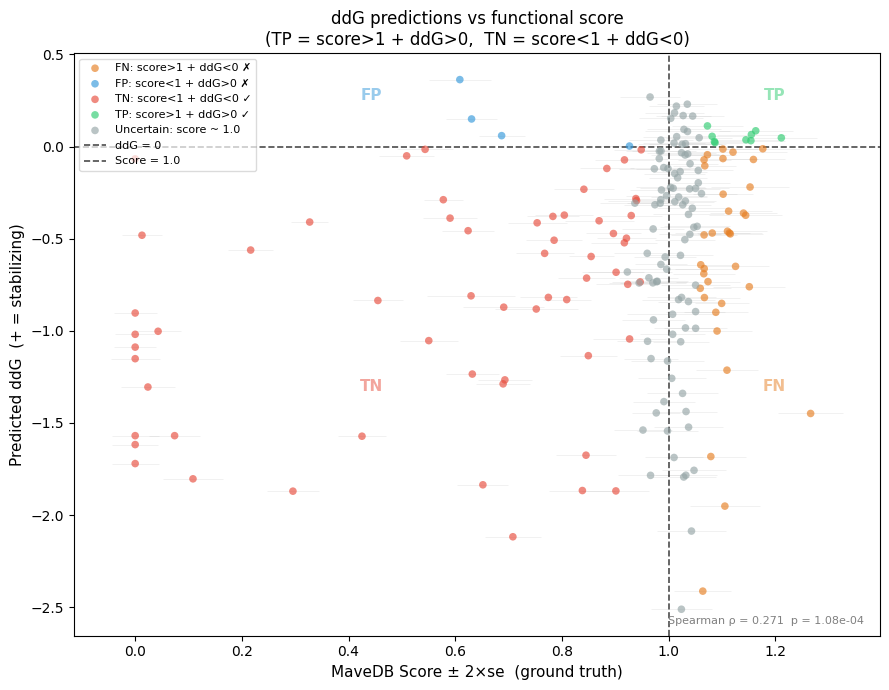

In [95]:
fig, ax = plt.subplots(figsize=(9, 7))

for cat, group in df.groupby('category'):
    ax.scatter(
        group['score'],
        group['ddG_predicted'],
        c=COLOR_MAP[cat],
        label=LABELS[cat],
        alpha=0.65, s=30, edgecolors='none', zorder=3
    )

# Score error bars
ax.errorbar(
    df['score'], df['ddG_predicted'],
    xerr=2 * df['se'].abs(),
    fmt='none', alpha=0.15, color='gray', linewidth=0.5, zorder=2
)

# Threshold lines
ax.axhline(DDG_THRESH,   color='black',  linestyle='--',
           linewidth=1.2, alpha=0.7, label='ddG = 0')
ax.axvline(SCORE_THRESH, color='black',  linestyle='--',
           linewidth=1.2, alpha=0.7, label='Score = 1.0')

# Region labels
xlim = ax.get_xlim()
ylim = ax.get_ylim()
mid_y_top = (ylim[1] + DDG_THRESH) / 2
mid_y_bot = (ylim[0] + DDG_THRESH) / 2
mid_x_left  = (xlim[0] + SCORE_THRESH) / 2
mid_x_right = (xlim[1] + SCORE_THRESH) / 2

for x, y, txt in [
    (mid_x_right, mid_y_top, 'TP'),
    (mid_x_left,  mid_y_bot, 'TN'),
    (mid_x_left,  mid_y_top, 'FP'),
    (mid_x_right, mid_y_bot, 'FN'),
]:
    ax.text(x, y, txt, ha='center', fontsize=11,
            color=COLOR_MAP[txt], fontweight='bold', alpha=0.5)

spearman = scipy.stats.spearmanr(df['score'], df['ddG_predicted'])
ax.text(0.98, 0.02,
        f"Spearman ρ = {spearman.statistic:.3f}  p = {spearman.pvalue:.2e}",
        transform=ax.transAxes, ha='right', fontsize=8, color='gray')

ax.set_xlabel("MaveDB Score ± 2×se  (ground truth)", fontsize=11)
ax.set_ylabel("Predicted ddG  (+ = stabilizing)", fontsize=11)
ax.set_title("ddG predictions vs functional score\n"
             "(TP = score>1 + ddG>0,  TN = score<1 + ddG<0)",
             fontsize=12)
ax.legend(fontsize=8, loc='upper left', framealpha=0.7)
plt.tight_layout()
plt.savefig('outputs/quadrant_scatter_final.png', dpi=150)
plt.show()

In [96]:
print(f"Negative se values: {(df['se'] < 0).sum()}")
print(f"Min se: {df['se'].min():.4f}")
print(df[df['se'] < 0][['Mutation', 'score', 'se']].head(10))

Negative se values: 8
Min se: -0.0231
        Mutation  score        se
191  p.Arg342Gln    0.0 -0.022029
192  p.Thr242Met    0.0 -0.022045
193   p.Gly36Arg    0.0 -0.018566
194  p.Ser147Tyr    0.0 -0.019915
195  p.Thr156Met    0.0 -0.020179
196  p.Ser179Leu    0.0 -0.018090
197  p.Gly203Arg    0.0 -0.023093
198  p.Gly206Arg    0.0 -0.021557


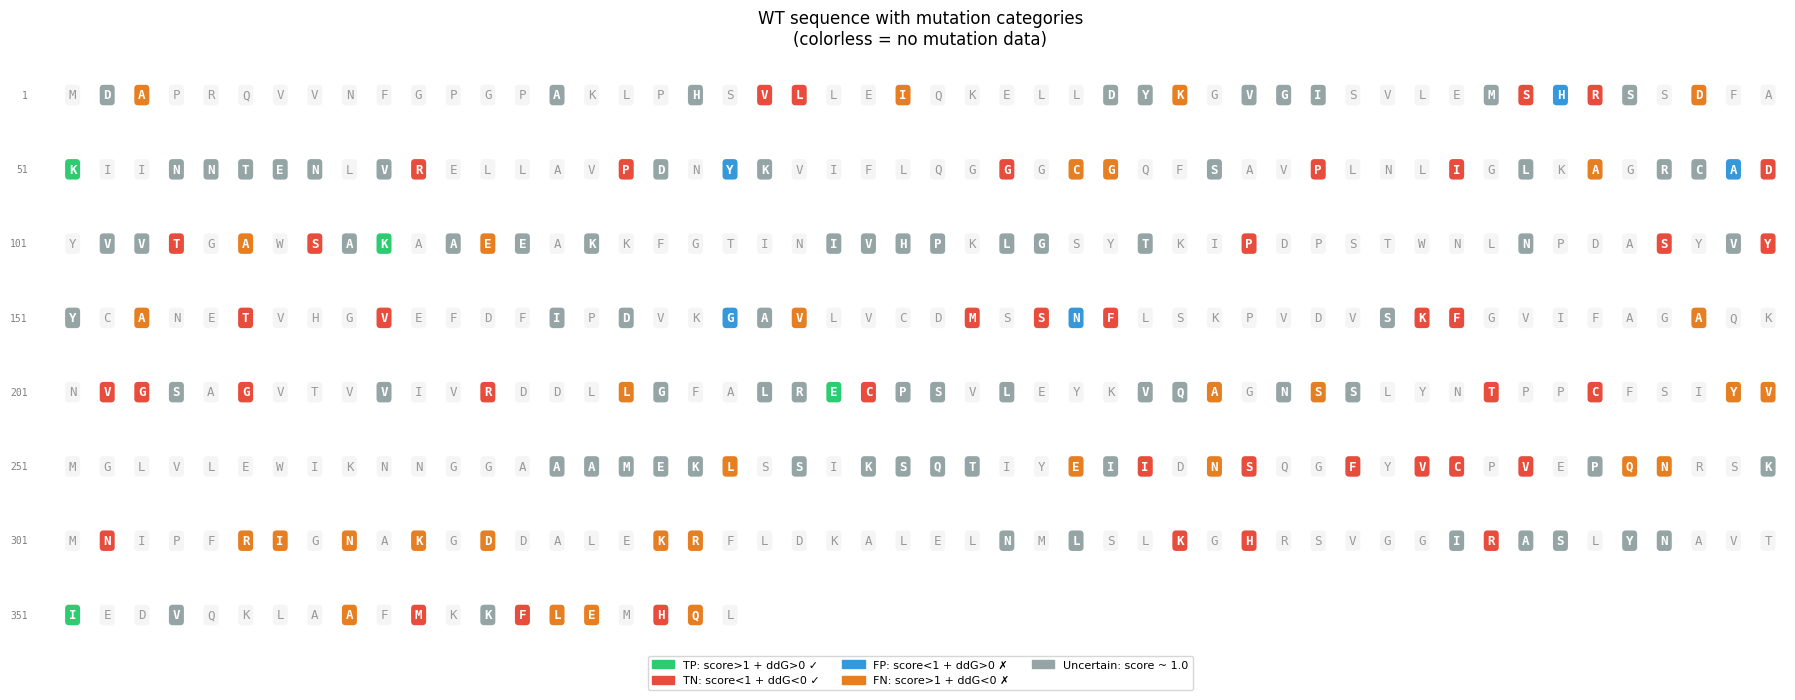

Saved to outputs/colourindex_wtseq.png


In [101]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('outputs', exist_ok=True)

# Build position → category lookup
pos_to_cat = dict(zip(pos_category['position'], pos_category['dominant_category']))

# ── Layout: wrap sequence into rows of N characters ──────────────────────────
CHARS_PER_ROW = 50
rows = [wt_sequence[i:i+CHARS_PER_ROW] for i in range(0, len(wt_sequence), CHARS_PER_ROW)]
n_rows = len(rows)

fig, ax = plt.subplots(figsize=(18, n_rows * 0.7 + 1.5))
ax.set_xlim(0, CHARS_PER_ROW)
ax.set_ylim(-0.5, n_rows)
ax.axis('off')

for row_idx, row_seq in enumerate(rows):
    y = n_rows - row_idx - 1  # top to bottom
    for col_idx, aa in enumerate(row_seq):
        pos = row_idx * CHARS_PER_ROW + col_idx + 1  # 1-indexed
        cat = pos_to_cat.get(pos, None)

        if cat is not None:
            facecolor = COLOR_MAP[cat]
            textcolor = 'white'
            fontweight = 'bold'
        else:
            facecolor = '#f5f5f5'
            textcolor = '#999999'
            fontweight = 'normal'

        ax.text(
            col_idx + 0.5, y + 0.5, aa,
            ha='center', va='center',
            fontsize=9, fontweight=fontweight, color=textcolor,
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=facecolor, edgecolor='none')
        )

    # Row position label on the left
    start_pos = row_idx * CHARS_PER_ROW + 1
    ax.text(-0.8, y + 0.5, str(start_pos),
            ha='right', va='center', fontsize=7, color='gray', fontfamily='monospace')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COLOR_MAP[cat], label=LABELS[cat])
    for cat in ['TP', 'TN', 'FP', 'FN', 'UNCERTAIN']
]
ax.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08 * (1 / n_rows)),
    ncol=3, fontsize=8, framealpha=0.8
)

ax.set_title("WT sequence with mutation categories\n(colorless = no mutation data)",
             fontsize=12, pad=10)

plt.tight_layout()
plt.savefig('outputs/colourindex_wtseq.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/colourindex_wtseq.png")

KeyError: 'TP'

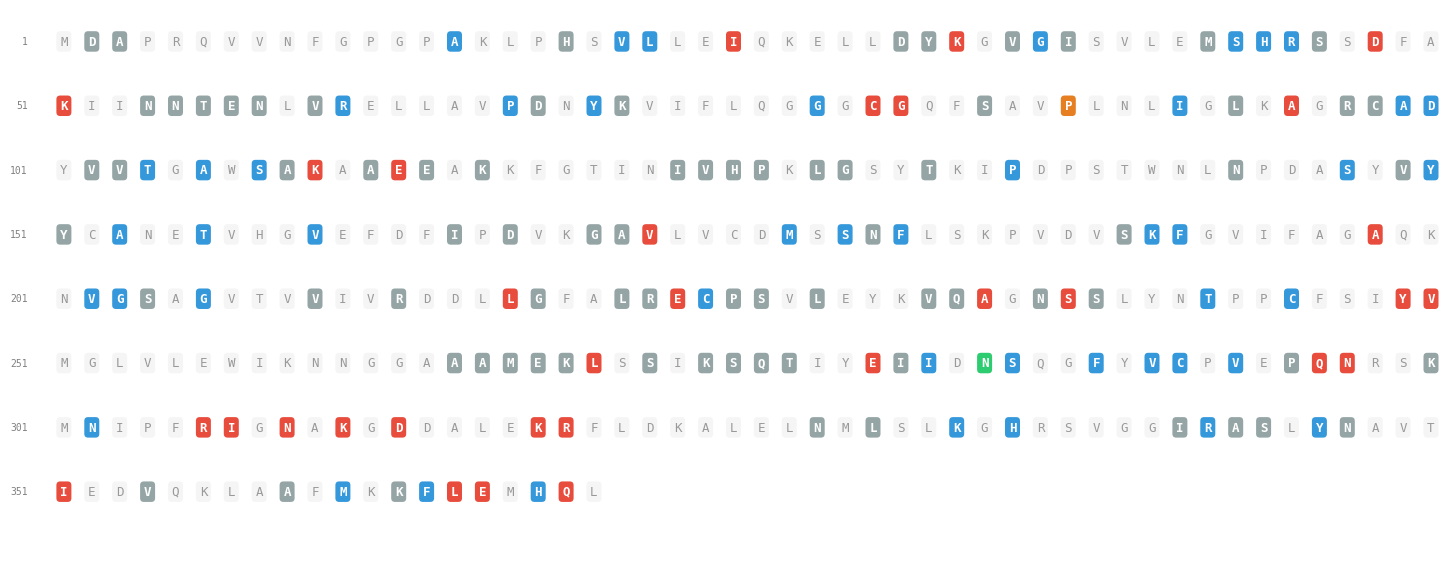

In [104]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import re

def parse_position(mut_str):
    match = re.search(r'(\d+)', str(mut_str))
    return int(match.group(1)) if match else None

df['position'] = df['Mutation'].apply(parse_position)

os.makedirs('outputs', exist_ok=True)

CHARS_PER_ROW = 50

# ── For each position, pick mutation furthest from both thresholds ─────────────
df['dist_score'] = (df['score'] - SCORE_THRESH).abs()
df['dist_ddg']   = (df['ddG_predicted'] - DDG_THRESH).abs()
df['dist_total'] = df['dist_score'] + df['dist_ddg']

# Per position: row with maximum combined distance
pos_most_confident = (
    df.loc[df.groupby('position')['dist_total'].idxmax()]
    [['position', 'category', 'dist_total', 'score', 'ddG_predicted']]
    .reset_index(drop=True)
)
pos_to_cat = dict(zip(pos_most_confident['position'],
                      pos_most_confident['category']))

# ── Plot ──────────────────────────────────────────────────────────────────────
rows  = [wt_sequence[i:i+CHARS_PER_ROW]
         for i in range(0, len(wt_sequence), CHARS_PER_ROW)]
n_rows = len(rows)

fig, ax = plt.subplots(figsize=(18, n_rows * 0.7 + 1.5))
ax.set_xlim(0, CHARS_PER_ROW)
ax.set_ylim(-0.5, n_rows)
ax.axis('off')

for row_idx, row_seq in enumerate(rows):
    y = n_rows - row_idx - 1
    for col_idx, aa in enumerate(row_seq):
        pos = row_idx * CHARS_PER_ROW + col_idx + 1
        cat = pos_to_cat.get(pos, None)

        if cat is not None:
            facecolor  = COLOR_MAP[cat]
            textcolor  = 'white'
            fontweight = 'bold'
        else:
            facecolor  = '#f5f5f5'
            textcolor  = '#999999'
            fontweight = 'normal'

        ax.text(
            col_idx + 0.5, y + 0.5, aa,
            ha='center', va='center',
            fontsize=9, fontweight=fontweight, color=textcolor,
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor=facecolor, edgecolor='none')
        )

    # Row position label
    ax.text(-0.8, y + 0.5, str(row_idx * CHARS_PER_ROW + 1),
            ha='right', va='center', fontsize=7, color='gray',
            fontfamily='monospace')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COLOR_MAP[cat], label=LABELS[cat])
    for cat in ['TP', 'TN', 'FP', 'FN', 'UNCERTAIN']
]
ax.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3, fontsize=8, framealpha=0.8
)
ax.set_title(
    "WT sequence — color = most confident mutation per position\n"
    "(furthest from score=1.0 and ddG=0 thresholds, grey = no data)",
    fontsize=12, pad=10
)

plt.tight_layout()
plt.savefig('outputs/colourindex_mostconfident.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to outputs/colourindex_mostconfident.png")

# ── Print summary ─────────────────────────────────────────────────────────────
print("\nMost confident mutation per position:")
for _, row in pos_most_confident.sort_values('position').iterrows():
    pos = int(row['position'])
    aa  = wt_sequence[pos-1] if 1 <= pos <= len(wt_sequence) else '?'
    print(f"  Position {pos:4d} ({aa}): {row['category']:12s} "
          f"score={row['score']:.3f}  ddG={row['ddG_predicted']:.3f}  "
          f"dist={row['dist_total']:.3f}")

Computing MC dropout uncertainty...
  50/199 done
  100/199 done
  150/199 done
Done!

Category counts:
category
UNCERTAIN       96
DAM_DESTAB      61
HYPER_DESTAB    39
DAM_STAB         3


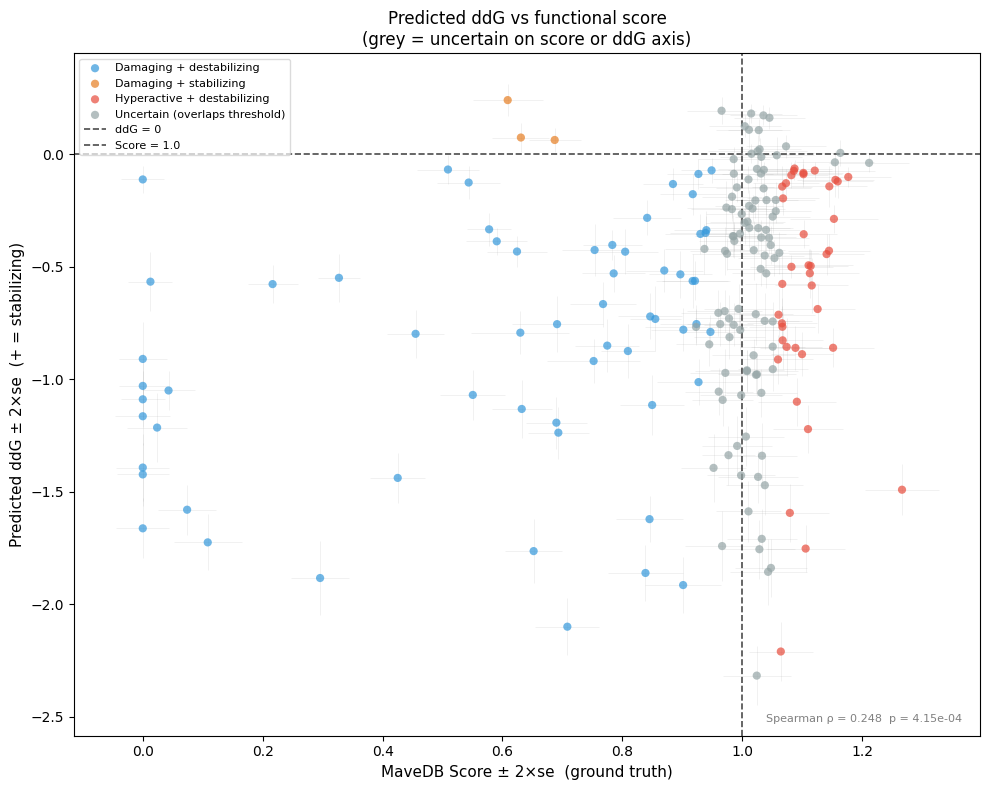

Saved to outputs/quadrant_scatter_uncertainty.png


In [105]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import scipy.stats
import os

os.makedirs('outputs', exist_ok=True)

# ── Monte Carlo Dropout for ddG uncertainty ───────────────────────────────────
N_SAMPLES = 30  # number of stochastic forward passes

def predict_ddG_mc(mut_seq: str, wt_seq: str, n_samples: int = N_SAMPLES):
    """
    Returns (mean_ddG, se_ddG) using Monte Carlo dropout.
    Model must have dropout layers for this to work.
    """
    model.train()  # dropout ON
    preds = []
    with torch.no_grad():
        x = build_input_vector(mut_seq, wt_seq).unsqueeze(0)
        for _ in range(n_samples):
            preds.append(model(x).item())
    model.eval()   # restore eval mode
    preds = np.array(preds)
    return preds.mean(), preds.std() / np.sqrt(n_samples)  # mean, SE

# Compute MC dropout uncertainty for all rows
print("Computing MC dropout uncertainty...")
ddg_means, ddg_ses = [], []
for idx, row in df.iterrows():
    mean, se = predict_ddG_mc(row['Full_Sequence'], wt_sequence)
    ddg_means.append(mean)
    ddg_ses.append(se)
    if (idx + 1) % 50 == 0:
        print(f"  {idx + 1}/{len(df)} done")

df['ddG_mean'] = ddg_means
df['ddG_se']   = ddg_ses
print("Done!")

# ── Redefine thresholds & categories using uncertainty on BOTH axes ───────────
SCORE_THRESH = 1.0
DDG_THRESH   = 0.0

# Score: confident if 2*se doesn't cross threshold
df['score_confident_high'] = (df['score'] - 2 * df['se'].abs()) > SCORE_THRESH
df['score_confident_low']  = (df['score'] + 2 * df['se'].abs()) < SCORE_THRESH
df['score_uncertain']      = ~df['score_confident_high'] & ~df['score_confident_low']

# ddG: confident if 2*se doesn't cross zero
df['ddg_confident_pos'] = (df['ddG_mean'] - 2 * df['ddG_se']) > DDG_THRESH
df['ddg_confident_neg'] = (df['ddG_mean'] + 2 * df['ddG_se']) < DDG_THRESH
df['ddg_uncertain']     = ~df['ddg_confident_pos'] & ~df['ddg_confident_neg']

# ── Assign categories (renamed — no more TP/FP/FN/TN) ────────────────────────
def assign_category(row):
    score_hi  = row['score_confident_high']
    score_lo  = row['score_confident_low']
    score_unc = row['score_uncertain']
    ddg_pos   = row['ddg_confident_pos']
    ddg_neg   = row['ddg_confident_neg']
    ddg_unc   = row['ddg_uncertain']

    if score_unc or ddg_unc:
        return 'UNCERTAIN'
    elif score_hi and ddg_pos:
        return 'HYPER_STAB'      # hyperactive + stabilizing
    elif score_hi and ddg_neg:
        return 'HYPER_DESTAB'    # hyperactive + destabilizing
    elif score_lo and ddg_neg:
        return 'DAM_DESTAB'      # damaging + destabilizing
    elif score_lo and ddg_pos:
        return 'DAM_STAB'        # damaging + stabilizing
    else:
        return 'UNCERTAIN'

df['category'] = df.apply(assign_category, axis=1)

COLOR_MAP = {
    'HYPER_STAB':   '#2ecc71',  # green  — hyperactive + stabilizing
    'HYPER_DESTAB': '#e74c3c',  # red    — hyperactive + destabilizing
    'DAM_DESTAB':   '#3498db',  # blue   — damaging + destabilizing
    'DAM_STAB':     '#e67e22',  # orange — damaging + stabilizing
    'UNCERTAIN':    '#95a5a6',  # grey   — uncertain on either axis
}

LABELS = {
    'HYPER_STAB':   'Hyperactive + stabilizing',
    'HYPER_DESTAB': 'Hyperactive + destabilizing',
    'DAM_DESTAB':   'Damaging + destabilizing',
    'DAM_STAB':     'Damaging + stabilizing',
    'UNCERTAIN':    'Uncertain (overlaps threshold)',
}

print("\nCategory counts:")
print(df['category'].value_counts().to_string())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

for cat, group in df.groupby('category'):
    ax.scatter(
        group['score'],
        group['ddG_mean'],
        c=COLOR_MAP[cat],
        label=LABELS[cat],
        alpha=0.7, s=35, edgecolors='none', zorder=3
    )

# Error bars — both axes
ax.errorbar(
    df['score'], df['ddG_mean'],
    xerr=2 * df['se'].abs(),
    yerr=2 * df['ddG_se'],
    fmt='none', alpha=0.15, color='gray', linewidth=0.5, zorder=2
)

# Threshold lines
ax.axhline(DDG_THRESH,   color='black', linestyle='--',
           linewidth=1.2, alpha=0.7, label='ddG = 0')
ax.axvline(SCORE_THRESH, color='black', linestyle='--',
           linewidth=1.2, alpha=0.7, label='Score = 1.0')

spearman = scipy.stats.spearmanr(df['score'], df['ddG_mean'])
ax.text(0.98, 0.02,
        f"Spearman ρ = {spearman.statistic:.3f}  p = {spearman.pvalue:.2e}",
        transform=ax.transAxes, ha='right', fontsize=8, color='gray')

ax.set_xlabel("MaveDB Score ± 2×se  (ground truth)", fontsize=11)
ax.set_ylabel("Predicted ddG ± 2×se  (+ = stabilizing)", fontsize=11)
ax.set_title("Predicted ddG vs functional score\n"
             "(grey = uncertain on score or ddG axis)",
             fontsize=12)
ax.legend(fontsize=8, loc='upper left', framealpha=0.7)

plt.tight_layout()
plt.savefig('outputs/quadrant_scatter_uncertainty.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to outputs/quadrant_scatter_uncertainty.png")

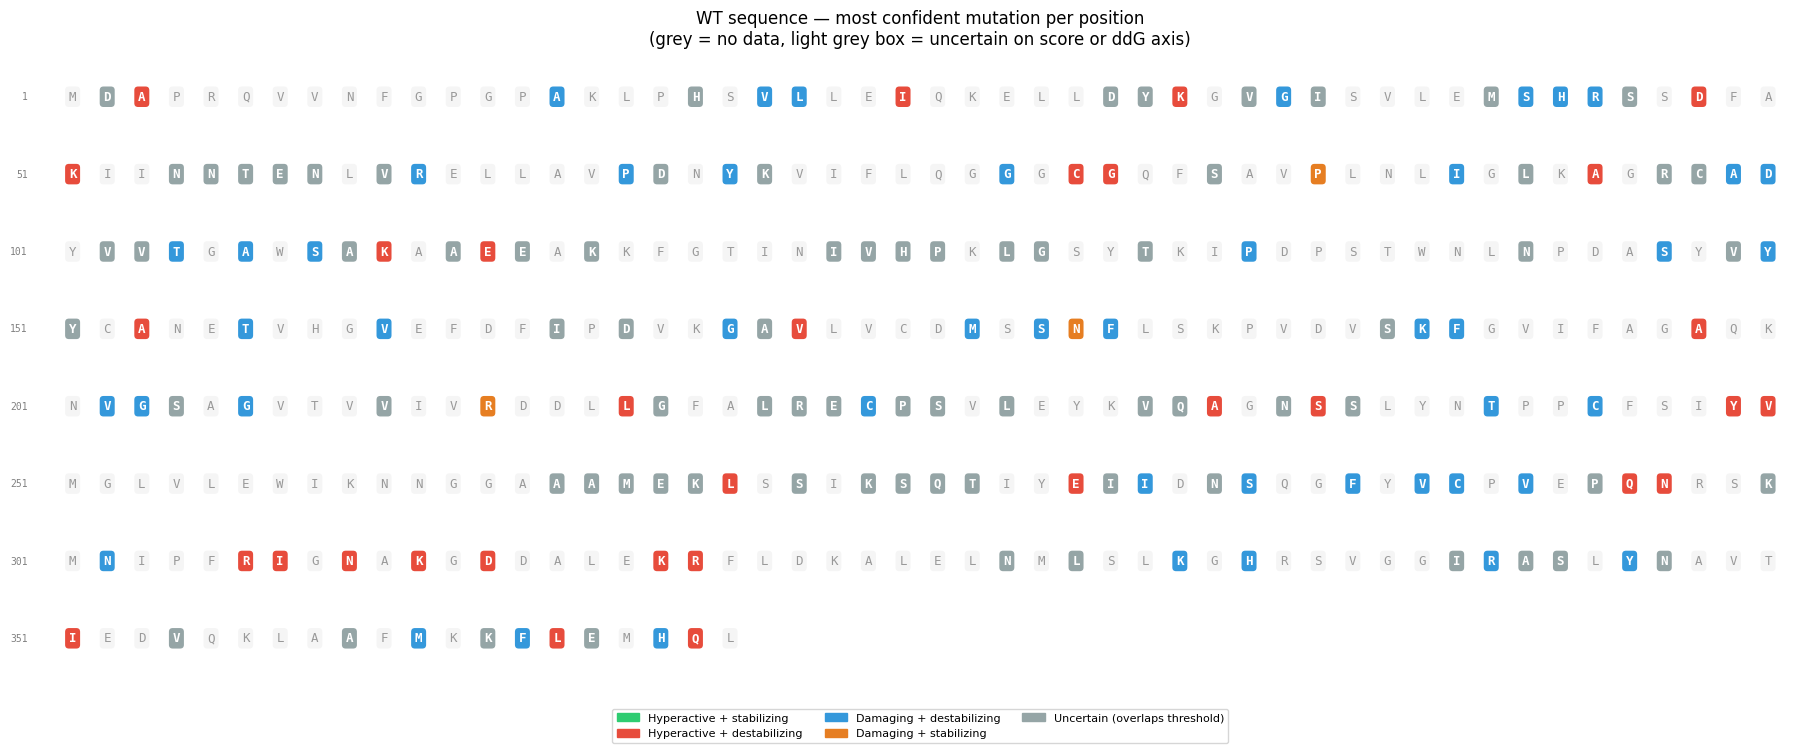

Saved to outputs/colourindex_uncertainty.png

Most confident mutation per position:
  Position    2 (D): UNCERTAIN       score=1.035  ddG=0.174 ± 0.044  dist=0.209
  Position    3 (A): HYPER_DESTAB    score=1.086  ddG=-0.073 ± 0.039  dist=0.159
  Position   15 (A): DAM_DESTAB      score=0.850  ddG=-1.114 ± 0.133  dist=1.265
  Position   19 (H): UNCERTAIN       score=0.975  ddG=-0.442 ± 0.071  dist=0.467
  Position   21 (V): DAM_DESTAB      score=0.901  ddG=-1.915 ± 0.123  dist=2.014
  Position   22 (L): DAM_DESTAB      score=0.551  ddG=-1.070 ± 0.111  dist=1.519
  Position   25 (I): HYPER_DESTAB    score=1.100  ddG=-0.888 ± 0.098  dist=0.988
  Position   31 (D): UNCERTAIN       score=1.058  ddG=-0.004 ± 0.083  dist=0.061
  Position   32 (Y): UNCERTAIN       score=1.062  ddG=-0.437 ± 0.092  dist=0.499
  Position   33 (K): HYPER_DESTAB    score=1.060  ddG=-0.713 ± 0.115  dist=0.773
  Position   35 (V): UNCERTAIN       score=1.051  ddG=-0.743 ± 0.088  dist=0.793
  Position   36 (G): DAM_D

In [106]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import re

def parse_position(mut_str):
    match = re.search(r'(\d+)', str(mut_str))
    return int(match.group(1)) if match else None

df['position'] = df['Mutation'].apply(parse_position)

os.makedirs('outputs', exist_ok=True)

CHARS_PER_ROW = 50

# ── For each position, pick mutation furthest from both thresholds ─────────────
df['dist_score'] = (df['score'] - SCORE_THRESH).abs()
df['dist_ddg']   = (df['ddG_mean'] - DDG_THRESH).abs()
df['dist_total'] = df['dist_score'] + df['dist_ddg']

pos_most_confident = (
    df.loc[df.groupby('position')['dist_total'].idxmax()]
    [['position', 'category', 'dist_total', 'score', 'ddG_mean', 'ddG_se']]
    .reset_index(drop=True)
)
pos_to_cat = dict(zip(pos_most_confident['position'],
                      pos_most_confident['category']))

# ── Plot ──────────────────────────────────────────────────────────────────────
rows   = [wt_sequence[i:i+CHARS_PER_ROW]
          for i in range(0, len(wt_sequence), CHARS_PER_ROW)]
n_rows = len(rows)

fig, ax = plt.subplots(figsize=(18, n_rows * 0.7 + 2))
ax.set_xlim(0, CHARS_PER_ROW)
ax.set_ylim(-0.5, n_rows)
ax.axis('off')

for row_idx, row_seq in enumerate(rows):
    y = n_rows - row_idx - 1
    for col_idx, aa in enumerate(row_seq):
        pos = row_idx * CHARS_PER_ROW + col_idx + 1
        cat = pos_to_cat.get(pos, None)

        if cat is not None:
            facecolor  = COLOR_MAP[cat]
            textcolor  = 'white'
            fontweight = 'bold'
        else:
            facecolor  = '#f5f5f5'
            textcolor  = '#999999'
            fontweight = 'normal'

        ax.text(
            col_idx + 0.5, y + 0.5, aa,
            ha='center', va='center',
            fontsize=9, fontweight=fontweight, color=textcolor,
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor=facecolor, edgecolor='none')
        )

    # Row position label
    ax.text(-0.8, y + 0.5, str(row_idx * CHARS_PER_ROW + 1),
            ha='right', va='center', fontsize=7,
            color='gray', fontfamily='monospace')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COLOR_MAP[cat], label=LABELS[cat])
    for cat in ['HYPER_STAB', 'HYPER_DESTAB', 'DAM_DESTAB', 'DAM_STAB', 'UNCERTAIN']
]
ax.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3, fontsize=8, framealpha=0.8
)
ax.set_title(
    "WT sequence — most confident mutation per position\n"
    "(grey = no data, light grey box = uncertain on score or ddG axis)",
    fontsize=12, pad=10
)

plt.tight_layout()
plt.savefig('outputs/colourindex_uncertainty.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to outputs/colourindex_uncertainty.png")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\nMost confident mutation per position:")
for _, row in pos_most_confident.sort_values('position').iterrows():
    pos = int(row['position'])
    aa  = wt_sequence[pos-1] if 1 <= pos <= len(wt_sequence) else '?'
    print(f"  Position {pos:4d} ({aa}): {row['category']:15s} "
          f"score={row['score']:.3f}  "
          f"ddG={row['ddG_mean']:.3f} ± {2*row['ddG_se']:.3f}  "
          f"dist={row['dist_total']:.3f}")